In [1]:
import sys
sys.path.append("../src")

import torch
import torch.nn as nn
import random
import matplotlib.pyplot as plt
import os

from data import generate_examples
from model import DyckTransformer

VOCAB = ["(", ")", "[", "]", "[PAD]", "[CLS]", "[SEP]"]
stoi = {tok: i for i, tok in enumerate(VOCAB)}
itos = {i: tok for tok, i in stoi.items()}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 64

def accuracy(logits, y):
    preds = torch.argmax(logits, dim=1)
    return (preds == y).float().mean().item()

In [2]:
# One dataset per stage, each contains only sequences up to that depth
print("Generating curriculum data...")
curriculum_data = {
    1: generate_examples(12500, max_depth=1, task="detection"),
    2: generate_examples(12500, max_depth=2, task="detection"),
    3: generate_examples(12500, max_depth=3, task="detection"),
    4: generate_examples(12500, max_depth=4, task="detection"),
}
dev_data = generate_examples(5000, max_depth=4, task="detection")
print("Done.")

Generating curriculum data...
Done.


In [3]:
model = DyckTransformer(
    vocab_size=len(VOCAB),
    pad_idx=stoi["[PAD]"],
    num_edit_labels=6,
    d_model=128,
    n_heads=4,
    n_layers=2,
    max_len=80,
    dropout=0.1
)
torch.nn.init.zeros_(model.cls_head.bias)
torch.nn.init.xavier_uniform_(model.cls_head.weight)
model = model.to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

In [4]:
EPOCHS_PER_STAGE = 5
all_train_loss = []
all_train_acc = []
all_dev_acc = []
stage_boundaries = []  # to mark on the plot where stages change

for stage, max_depth in enumerate([1, 2, 3, 4], start=1):
    train_data = curriculum_data[max_depth]
    print(f"\n--- Stage {stage}: max_depth={max_depth} ---")

    for epoch in range(EPOCHS_PER_STAGE):
        # training
        model.train()
        total_loss, total_acc, n_batches = 0, 0, 0

        for i in range(0, len(train_data), batch_size):
            batch = train_data[i:i+batch_size]
            xs, ys = zip(*batch)
            xs = torch.tensor([[stoi[t] for t in x] for x in xs]).to(device)
            ys = torch.tensor(ys).to(device)
            cls_logits, _ = model(xs)
            loss = loss_fn(cls_logits, ys)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()
            total_acc += accuracy(cls_logits, ys)
            n_batches += 1

        avg_loss = total_loss / n_batches
        avg_acc = total_acc / n_batches
        all_train_loss.append(avg_loss)
        all_train_acc.append(avg_acc)

        # dev evaluation
        model.eval()
        dev_acc, n_dev = 0, 0
        with torch.no_grad():
            for i in range(0, len(dev_data), batch_size):
                batch = dev_data[i:i+batch_size]
                xs, ys = zip(*batch)
                xs = torch.tensor([[stoi[t] for t in x] for x in xs]).to(device)
                ys = torch.tensor(ys).to(device)
                cls_logits, _ = model(xs)
                dev_acc += accuracy(cls_logits, ys)
                n_dev += 1
        dev_acc /= n_dev
        all_dev_acc.append(dev_acc)

        print(f"  epoch {epoch} | loss {avg_loss:.4f} | train acc {avg_acc:.4f} | dev acc {dev_acc:.4f}")

    # save model at end of each stage
    path = f"../results/models/curriculum_n{stage}_det_dyck_transformer.pt"
    torch.save(model.state_dict(), path)
    print(f"  Saved: {path}")
    stage_boundaries.append(len(all_train_loss))


--- Stage 1: max_depth=1 ---


c:\Users\sarav\projects\dyck_transformer\.pixi\envs\default\Lib\site-packages\torch\nn\modules\transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\bld\libtorch_1772176602146\work\aten\src\ATen\NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(


  epoch 0 | loss 0.3365 | train acc 0.8198 | dev acc 0.5358
  epoch 1 | loss 0.0072 | train acc 0.9978 | dev acc 0.5358
  epoch 2 | loss 0.0079 | train acc 0.9981 | dev acc 0.5358
  epoch 3 | loss 0.0034 | train acc 0.9991 | dev acc 0.5358
  epoch 4 | loss 0.0018 | train acc 0.9994 | dev acc 0.5358
  Saved: ../results/models/curriculum_n1_det_dyck_transformer.pt

--- Stage 2: max_depth=2 ---
  epoch 0 | loss 0.6036 | train acc 0.7751 | dev acc 0.8681
  epoch 1 | loss 0.1468 | train acc 0.9473 | dev acc 0.9735
  epoch 2 | loss 0.0784 | train acc 0.9726 | dev acc 0.9840
  epoch 3 | loss 0.0873 | train acc 0.9711 | dev acc 0.8230
  epoch 4 | loss 0.0591 | train acc 0.9822 | dev acc 0.4672
  Saved: ../results/models/curriculum_n2_det_dyck_transformer.pt

--- Stage 3: max_depth=3 ---
  epoch 0 | loss 0.1420 | train acc 0.9543 | dev acc 0.9844
  epoch 1 | loss 0.0826 | train acc 0.9731 | dev acc 1.0000
  epoch 2 | loss 0.0645 | train acc 0.9798 | dev acc 1.0000
  epoch 3 | loss 0.0557 | trai

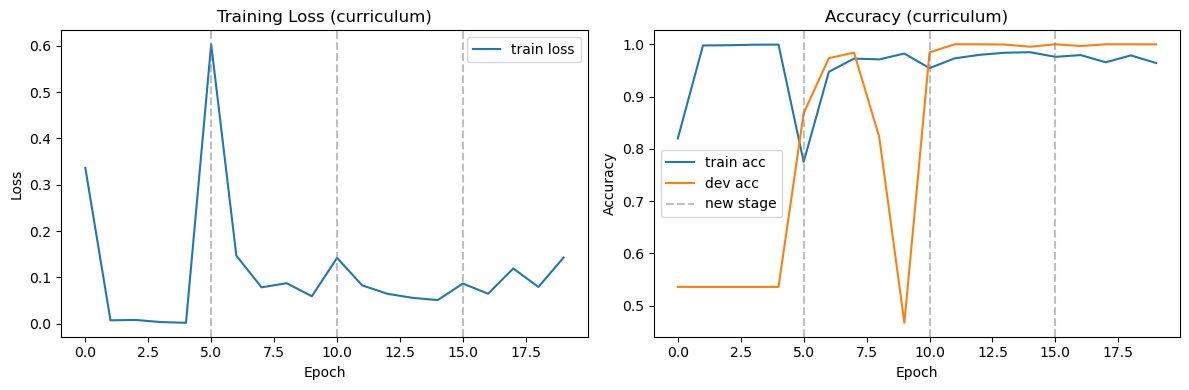

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(all_train_loss, label="train loss")
for b in stage_boundaries[:-1]:
    ax1.axvline(x=b, color='gray', linestyle='--', alpha=0.5)
ax1.set_title("Training Loss (curriculum)")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()

ax2.plot(all_train_acc, label="train acc")
ax2.plot(all_dev_acc, label="dev acc")
for b in stage_boundaries[:-1]:
    ax2.axvline(x=b, color='gray', linestyle='--', alpha=0.5, label="new stage" if b == stage_boundaries[0] else "")
ax2.set_title("Accuracy (curriculum)")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend()

os.makedirs("../results/figures", exist_ok=True)
plt.tight_layout()
plt.savefig("../results/figures/curriculum_training_curves.pdf")
plt.show()

In [6]:
from data import generate_examples

results = {}
for n in [5, 6, 7]:
    test_data = generate_examples(5000, max_depth=n, task="detection")
    correct, total = 0, 0
    model.eval()
    with torch.no_grad():
        for i in range(0, len(test_data), batch_size):
            batch = test_data[i:i+batch_size]
            xs, ys = zip(*batch)
            xs = torch.tensor([[stoi[t] for t in x] for x in xs]).to(device)
            ys = torch.tensor(ys).to(device)
            cls_logits, _ = model(xs)
            preds = torch.argmax(cls_logits, dim=1)
            correct += (preds == ys).sum().item()
            total += len(ys)
    results[n] = correct / total
    print(f"n={n}: {results[n]:.4f}")

n=5: 1.0000
n=6: 0.9994
n=7: 0.9984


In [7]:
standard = {5: 0.7296, 6: 0.6476, 7: 0.5796}  # your existing results

print(f"{'n':<6} {'standard':>10} {'curriculum':>12}")
for n in [5, 6, 7]:
    print(f"n={n}    {standard[n]:>10.4f} {results[n]:>12.4f}")

n        standard   curriculum
n=5        0.7296       1.0000
n=6        0.6476       0.9994
n=7        0.5796       0.9984
